<h1 style="font-size: 2rem;">Data Visualisation</h1>

The main aim here is to identify trends and seasonal variation by plotting the data as a line graph. There is a strong seasonal difference in productivity which is addresed using seasonal differencing and tested using Augmented dickey fuller test (ADF Test).

In [10]:
import plotly.express as px
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller

In [12]:
data= pd.read_csv('production_data.csv',index_col=0)
data.head()

,Production
Date,
1966-06-01,28.62
1966-11-01,1.82
1967-06-01,35.31
1967-11-01,2.30
1968-06-01,37.13


In [14]:
data.index = pd.to_datetime(data.index)

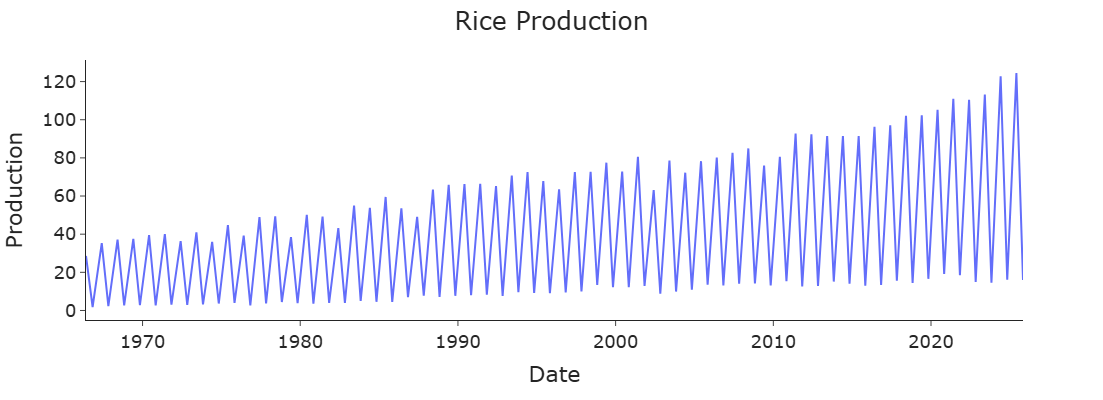

In [16]:
# Plot the data
fig = px.line(data, x=data.index, y='Production',
              labels=({'Production': 'Production', 'Month': 'Date'}))

fig.update_layout(template="simple_white", font=dict(size=18),
                  title_text='Rice Production', width=650, title_x=0.5, height=400)

fig.show()

The rice production time series shows a clear upward trend over time,
indicating long-term growth in production. Rice is mainly gwown as kharif crop and the difference in the production of two season will be very high. It is very important to consider this difference as we move forward. either we can use a time series model that can identify seasonality or we can apply some techniques to convert the data stationary.

To convert this data to a stationary data we can use several methods
1. Differencing
2. Logarithm Transformation
3. Decomposition models.
4. Boxcox Transformation.
   
Hence there is both an upward trend and Strong Seasonality. our first challenge is to remove seasonal component. Rice is Kharif crop so production in Rabi will be very low compared to Kharif. First we can remove seasonal component and see how data is behaving.

In [18]:
dataFixed=data.copy()

### Removing Seasonal Component

In [39]:
data["Production_diff"] = data["Production"].diff(periods=2)


In [41]:
def plotting(title, data, x, y, x_label, y_label):
    """General function to plot the passenger data."""
    # Check if x is a column or if we should use the index
    if x in data.columns:
        x_data = data[x]
    else:
        x_data = data.index
        
    fig = px.line(data, x=x_data, y=data[y], labels={x: x_label, y: y_label})

    fig.update_layout(template="simple_white", font=dict(size=18),
                      title_text=title, width=650,
                      title_x=0.5, height=400)

    fig.show()

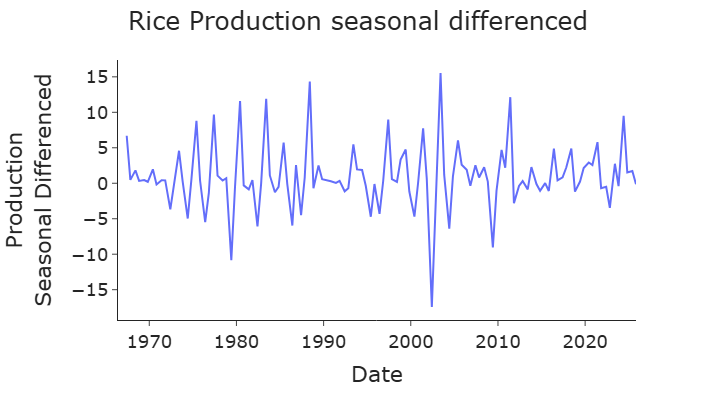

In [47]:
plotting(title='Rice Production seasonal differenced', data=data, x='index', y='Production_diff',
         x_label='Date', y_label='Production<br>Seasonal Differenced')

In [49]:
def adf_test(series):
    """Using an ADF test to determine if a series is stationary"""
    test_results = adfuller(series)
    print('ADF Statistic: ', test_results[0])
    print('P-Value: ', test_results[1])
    print('Critical Values:')
    for thres, adf_stat in test_results[4].items():
        print('\t%s: %.2f' % (thres, adf_stat)) 


adf_test(data["Passenger_Season_Diff"][2:])

ADF Statistic:  -7.857236424376283
P-Value:  5.401824847891276e-12
Critical Values:
	1%: -3.49
	5%: -2.89
	10%: -2.58


### Augmented Dickey–Fuller (ADF) Test

The ADF test is conducted to statistically verify whether the transformed
series is stationary.

- Null hypothesis (H₀): The series is non-stationary
- Alternative hypothesis (H₁): The series is stationary

A p-value less than 0.05 indicates rejection of the null hypothesis,
confirming stationarity of the differenced series.


In [51]:
data_diff_cleaned = data['Production_diff'].dropna()
print(data_diff_cleaned.head(10))  # Shows first 10 values

Date
1967-06-01    6.69
1967-11-01    0.48
1968-06-01    1.82
1968-11-01    0.33
1969-06-01    0.46
1969-11-01    0.21
1970-06-01    1.97
1970-11-01   -0.17
1971-06-01    0.43
1971-11-01    0.41
Name: Production_diff, dtype: float64


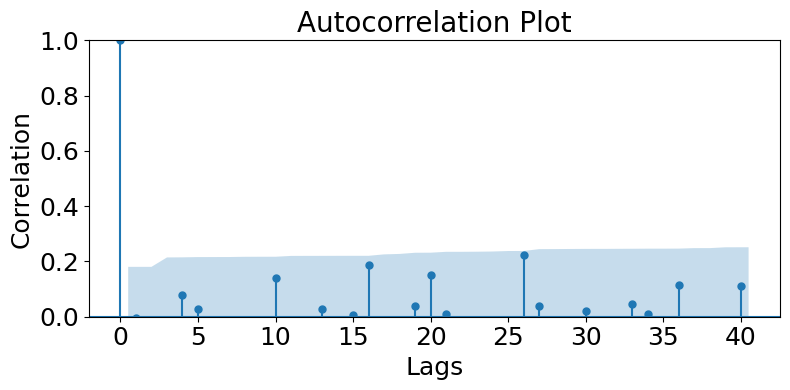

In [31]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
# Plot autocorrelation
plt.rc("figure", figsize=(8,4))
plot_acf(data_diff_cleaned, lags=40)
plt.ylim(0,1)
plt.xlabel('Lags', fontsize=18)
plt.ylabel('Correlation', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Autocorrelation Plot', fontsize=20)
plt.tight_layout()
plt.show()

### Autocorrelation Analysis

The autocorrelation plot (ACF) is used to examine the correlation of the
series with its lagged values. ACf is useful for selecting appropriate
ARIMA model parameters in subsequent analysis.


### Save differenced data as csv

In [34]:
data.head()

,Production,Passenger_Season_Diff
Date,,
1966-06-01,28.62,NaN
1966-11-01,1.82,NaN
1967-06-01,35.31,6.69
1967-11-01,2.30,0.48
1968-06-01,37.13,1.82


In [36]:

data.to_csv('Seasonal_differentiated.csv', index=True)